In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

from diffpy.mpdf import *

import maginteractions

from diffpy.structure import loadStructure

%matplotlib notebook

In [2]:
# build magstruc with primitive unit cell

triclinic = False

structure_file = 'NaMnO2Data/fitStruc_triShortRange_005K.cif'

NaMnO2 = loadStructure(structure_file)

if triclinic:
    a = NaMnO2.lattice.a
    b = NaMnO2.lattice.b
    c = NaMnO2.lattice.c
    alpha = NaMnO2.lattice.alpha
    beta = NaMnO2.lattice.beta
    gamma = NaMnO2.lattice.gamma
else:
    a = b = 3.17167
    c = 5.79900
    alpha = beta = 110.4993
    gamma = 53.5987
    NaMnO2.lattice.a = a
    NaMnO2.lattice.b = b
    NaMnO2.lattice.c = c
    NaMnO2.lattice.alpha = alpha
    NaMnO2.lattice.beta = beta
    NaMnO2.lattice.gamma = gamma
    
print(NaMnO2)

lattice=Lattice(a=3.17167, b=3.17167, c=5.799, alpha=110.499, beta=110.499, gamma=53.5987)
Na   0.500000 0.500000 0.500000 1.0000
Mn   0.000000 0.000000 0.000000 1.0000
O    0.709026 0.704427 0.204309 1.0000
O    0.290974 0.295573 0.795691 1.0000


In [3]:
mspec = MagSpecies()
mspec.struc = NaMnO2
mspec.label = 'Mn3+'
mspec.strucIdxs = [0]
mspec.basisvecs = np.array([[1.0, 1.0, 0]])
mspec.origin = np.array([0, 0, 0])
mspec.ffparamkey = 'Mn3'

magstruc = MagStructure()
magstruc.loadSpecies(mspec)
magstruc.makeAll()

In [4]:
# populate spins with mcif

mcif = 'NaMnO2Data/1.409_NaMnO2.mcif'
mstruc0 = create_from_mcif(mcif, ffparamkey='Mn2')
mstruc0.makeAll()

# rotate mcif spins/atoms to match current magstruc orientation
theta = -1.0571653032274788
rotation_matrix = np.array([[np.cos(theta), -np.sin(theta), 0],
                           [np.sin(theta), np.cos(theta), 0],
                           [0, 0, 1]])

magstruc.spins = mstruc0.spins @ rotation_matrix
magstruc.atoms = mstruc0.atoms @ rotation_matrix
magstruc.calcIdxs = mstruc0.calcIdxs

MagStructure creation from mcif file successful.


<IPython.core.display.Javascript object>


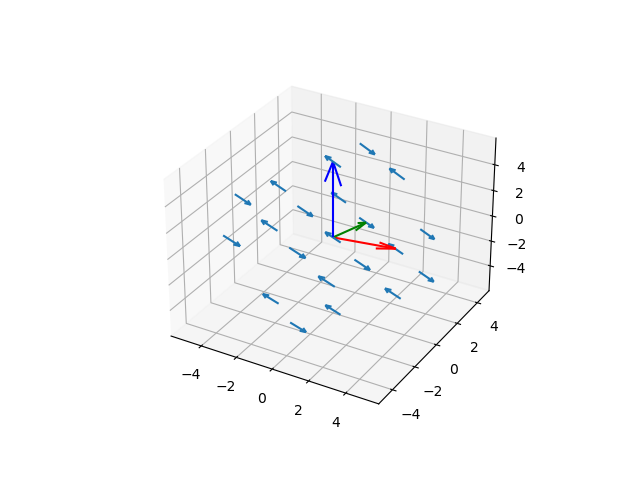

In [5]:
distances = np.apply_along_axis(np.linalg.norm, 1, magstruc.atoms)
viewmask = distances < 6
magstruc.visualize(magstruc.atoms[viewmask], magstruc.spins[viewmask], showcrystalaxes=True)

In [36]:
### import data

high_idx = 6 # index where paramagnet data starts

[data_temps, xi_data, xi_err] = np.loadtxt('NaMnO2Data/mPDFresults_NaMnO2_xi-vs-T.txt',
                                           delimiter = ' ', skiprows = 2).T
[data_temps_high, xi_high_data, xi_high_err] = np.loadtxt('NaMnO2Data/mPDFresults_NaMnO2_xi-vs-T.txt',
                                                          delimiter = ' ', skiprows = 2)[high_idx:].T

[_, lmop_data, lmop_err] = np.loadtxt('NaMnO2Data/mPDFresults_NaMnO2_m-vs-T.txt',
                                      delimiter = ' ', skiprows = 2).T
[_, lmop_high_data, lmop_high_err] = np.loadtxt('NaMnO2Data/mPDFresults_NaMnO2_m-vs-T.txt',
                                                delimiter = ' ', skiprows = 2)[high_idx:].T

lmop_data = 2 * np.sqrt(lmop_data)
lmop_err = 0.5 * lmop_data * lmop_err / (lmop_data / 2) ** 2

lmop_high_data = 2 * np.sqrt(lmop_high_data)
lmop_high_err = 0.5 * lmop_high_data * lmop_high_err / (lmop_high_data / 2) ** 2

# Previously published values

In [7]:
temps = data_temps # np.linspace(0.1,600.0,20)

In [8]:
j_ij_zorko = -65.0 * np.array([1, 0.44]) # Zorko 2008
j_ij_dally = np.array([-6.16, -0.77])/8.617333262e-2 # Dally 2018

j_ij_wadhwa_1 = np.array([-11.3,-3.26])/8.617333262e-2 # Wadhwa 2025
j_ij_wadhwa_2 = np.array([-3.87,-0.82])/8.617333262e-2
j_ij_wadhwa_3 = np.array([-6.37,-0.65])/8.617333262e-2
j_ij_wadhwa_4 = np.array([-6.1,-0.55])/8.617333262e-2

j_ijs = [j_ij_zorko, j_ij_dally, j_ij_wadhwa_1, j_ij_wadhwa_2, j_ij_wadhwa_3, j_ij_wadhwa_4]
j_ij_names = ["Zorko et al.", "Dally et al.", "Wadhwa 1", "Wadhwa 2", "Wadhwa 3", "Wadhwa 4"]

In [9]:
r_max = 5.0
spin_squared = 4

j_ij_test = j_ij_zorko
magint_test = maginteractions.MagInteractions(magstruc = magstruc, temperatures = temps, j_ij = j_ij_test,
                                              spin_squared = spin_squared, r_max = r_max)
magint_test.make_interaction_matrix()
magint_test.calculate_orf_reciprocal_space(n_bz_vecs = 4)

orfs_reciprocal_space = magint_test.orfs.copy()

/home/edison/Documents/Projects/MagInteractions/maginteractions.py:225: ComplexWarning: Casting complex values to real discards the imaginary part
  u_q[k] = eig_vecs.astype('float64')


<IPython.core.display.Javascript object>


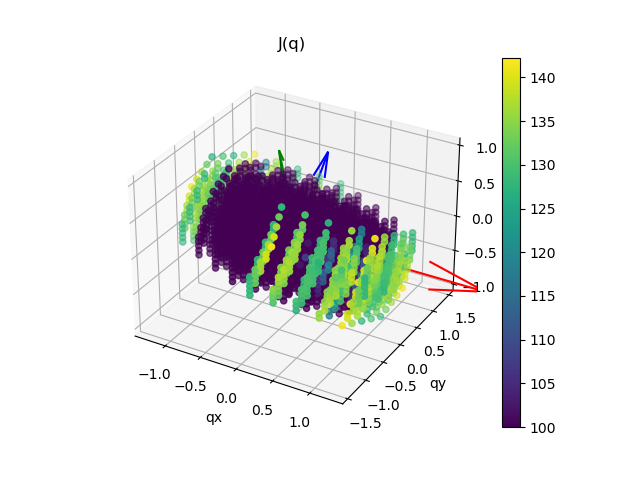

In [10]:
# visualize J(q)

import matplotlib.colors as mcolors

qxs, qys, qzs = magint_test.q_vecs.T

vmin = 100
vmax = 142.25

qa = 2 * np.pi / a
qb = 2 * np.pi / b
qc = 2 * np.pi / c


fig, ax = plt.subplots(subplot_kw = {"projection": "3d"})
norm = mcolors.Normalize(vmin = vmin, vmax = vmax)
j_q_plot = ax.scatter(qxs, qys, qzs, c = magint_test.j_q[:,-1], norm = norm)
fig.colorbar(j_q_plot)

rl_a, rl_b, rl_c = magint_test.recip_lats

ax.quiver(0, 0, 0, rl_a[0], rl_a[1], rl_a[2], pivot='tail', color='r')
ax.quiver(0, 0, 0, rl_b[0], rl_b[1], rl_b[2], pivot='tail', color='g')
ax.quiver(0, 0, 0, rl_c[0], rl_c[1], rl_c[2], pivot='tail', color='b')

ax.set_title('J(q)')
ax.set_xlabel('qx')
ax.set_ylabel('qy')
ax.set_zlabel('qz')
plt.show()

In [11]:
print('From BZ recreation')
print(f'Jq = {np.max(magint_test.j_q[:,-1])}')
idx = np.argmax(magint_test.j_q[:,-1], axis = None)
qmax = magint_test.q_vecs[idx]
print(f'q = {qmax}')
print(f'q = {qmax @ np.linalg.inv(magint_test.recip_lats)} (rlu)')
print(f'q = {qmax * np.array([1 / qa, 1 / qb, 1 / qc])} (units of 2pi/a)')

From BZ recreation
Jq = 141.37822901033488
q = [-1.14196154  0.62711063  0.        ]
q = [-0.29651174  0.29651174  0.        ] (rlu)
q = [-0.57644729  0.31655727  0.        ] (units of 2pi/a)


<IPython.core.display.Javascript object>


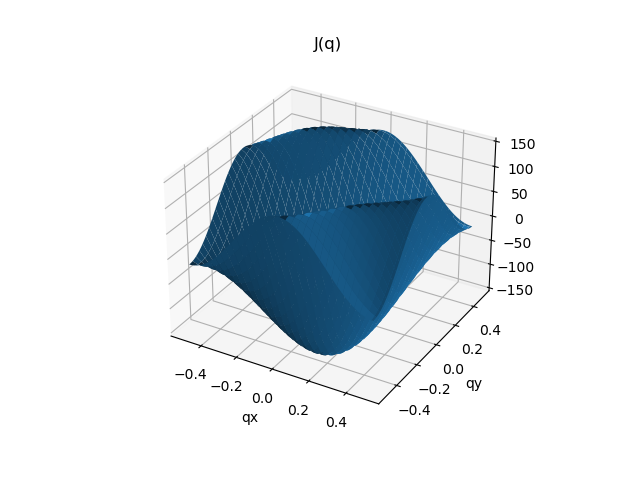

In [12]:
# visualize J(q) at qz=0

qa = 2 * np.pi / a
qb = 2 * np.pi / b
qc = 2 * np.pi / c

qx = np.linspace(-0.5, 0.5, 101)
qy = np.linspace(-0.5, 0.5, 101)
qx, qy = np.meshgrid(qx, qy)
qz = 0.0


j_qs = np.zeros((magint_test.N, 1) + qx.shape)
u_qs = np.zeros((magint_test.N, magint_test.N, 1) + qx.shape)
for i in range(qx.shape[0]):
    for j in range(qx.shape[1]):
        qv = np.array([qx[i,j], qy[i,j], qz]) @ magint_test.recip_lats
        j_qs[:,:,i,j], u_qs[:,:,:,i,j] = magint_test.calc_j_q(qv, return_eig_vecs = True)
        
j_qs = j_qs.reshape((magint_test.N,) + qx.shape)
u_qs = u_qs.reshape((magint_test.N,magint_test.N,) + qx.shape)

tidx = 5

for k in range(magint_test.N):
    fig, ax = plt.subplots(subplot_kw = {"projection": "3d"})
    ax.plot_surface(qx, qy, j_qs[k])
    ax.set_zlim(-150, 150)
    ax.set_title('J(q)')
    ax.set_xlabel('qx')
    ax.set_ylabel('qy')
    plt.show()

In [13]:
print(f'From qz = {qz} slice')
print(f'Jq = {np.max(j_qs)}')
idx = np.unravel_index(np.argmax(j_qs, axis=None), j_qs.shape)
qmax = np.array([qx[idx[1:]], qy[idx[1:]], qz]) @ magint_test.recip_lats
print(f'q = {qmax}')
print(f'q = {qmax @ np.linalg.inv(magint_test.recip_lats)} (rlu)')
print(f'q = {qmax * np.array([1 / qa, 1 / qb, 1 / qc])} (units of 2pi/a)')

From qz = 0.0 slice
Jq = 142.5707895607157
q = [ 1.09181896 -0.61333855  0.        ]
q = [ 0.28 -0.29  0.  ] (rlu)
q = [ 0.55113597 -0.3096053   0.        ] (units of 2pi/a)


<IPython.core.display.Javascript object>


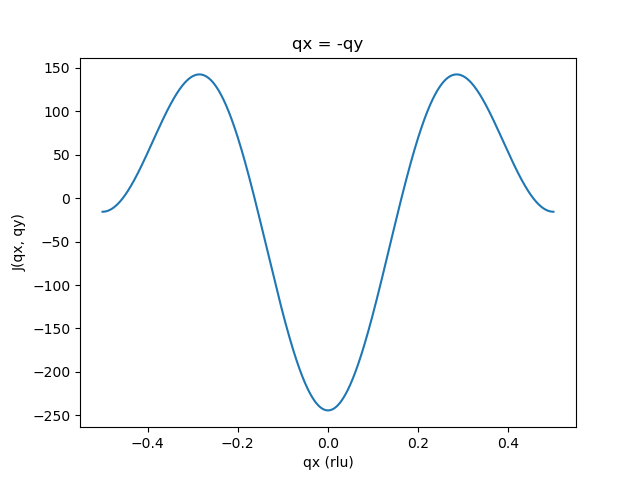

In [14]:
qxys = np.linspace(-0.5, 0.5, 1001)
jqxy = np.array([magint_test.calc_j_q(qxy * np.array([1, -1, 0]) @ magint_test.recip_lats)[0] for qxy in qxys])

fig, ax = plt.subplots()
ax.plot(qxys, jqxy)
ax.set_xlabel('qx (rlu)')
ax.set_ylabel('J(qx, qy)')
ax.set_title('qx = -qy')
plt.show()

<IPython.core.display.Javascript object>


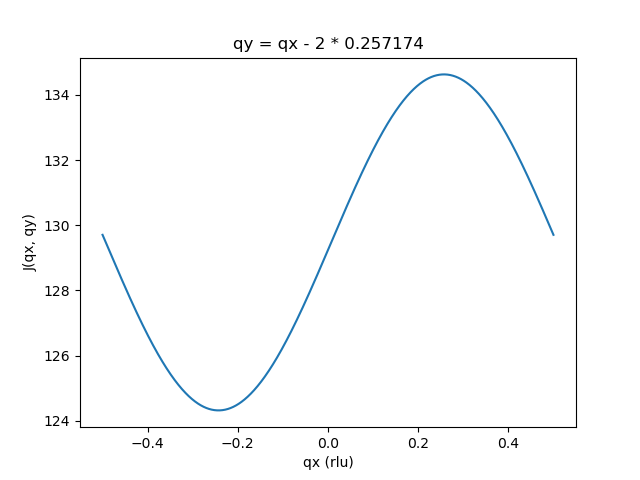

In [15]:
qxys = np.linspace(-0.5, 0.5, 1001)
jqxy = np.array([magint_test.calc_j_q(np.array([qxy, qxy - 2 * 0.257174, 0]) @ magint_test.recip_lats)[0]
                 for qxy in qxys])

fig, ax = plt.subplots()
ax.plot(qxys,jqxy)
ax.set_xlabel('qx (rlu)')
ax.set_ylabel('J(qx, qy)')
ax.set_title('qy = qx - 2 * 0.257174')
plt.show()

Maxima near:
(1/4, -1/4, 0)
(-1/4, 1/4, 0)

0.2853028694288763 -0.2853028694288762
25.17182841087256


<IPython.core.display.Javascript object>


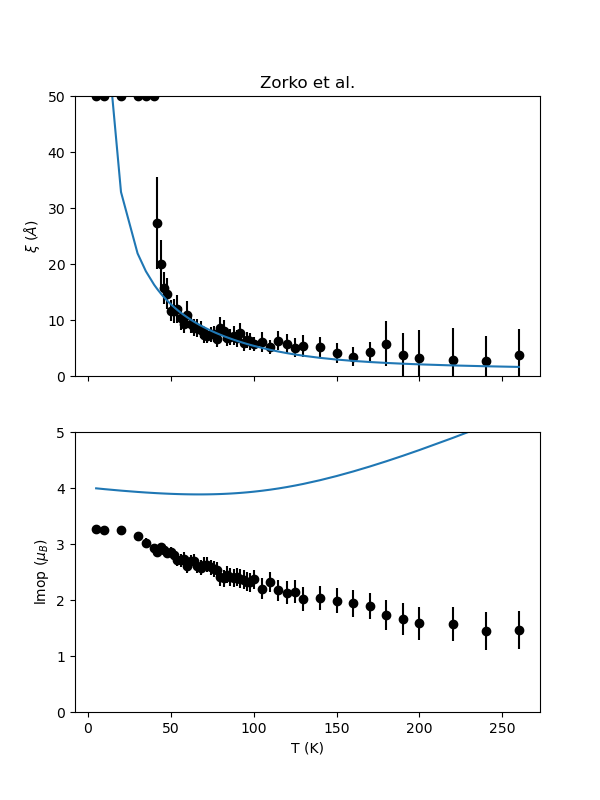

0.2599536713846443 -0.25995367138464437
998.8111486524951


<IPython.core.display.Javascript object>


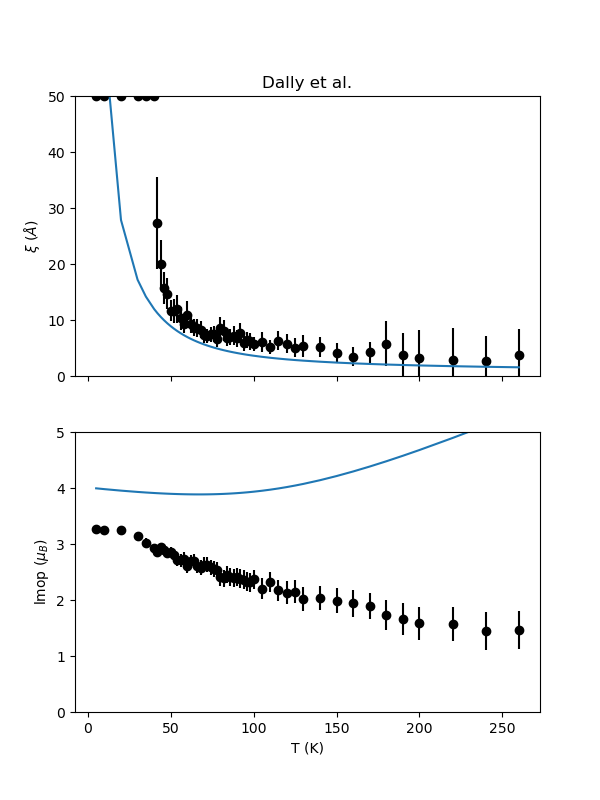

0.2730381185273264 -0.2730381185273264
272.15560629609354


<IPython.core.display.Javascript object>


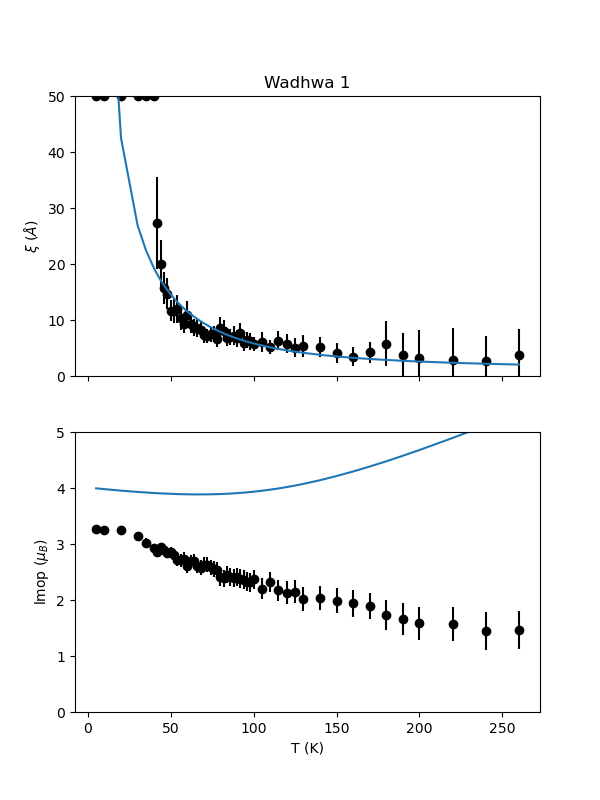

0.26689307866212775 -0.26689307866212775
2880.6684628543003


<IPython.core.display.Javascript object>


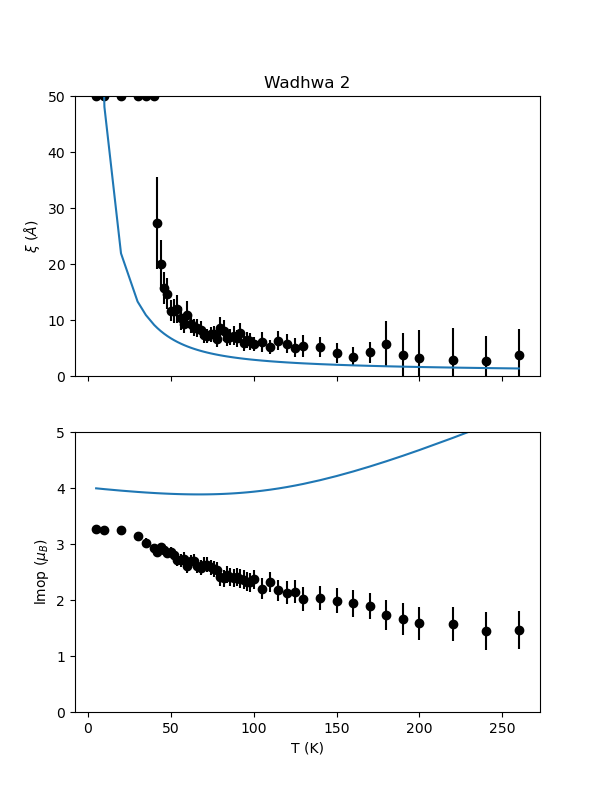

0.25812367719368956 -0.25812367719368956
919.289647119033


<IPython.core.display.Javascript object>


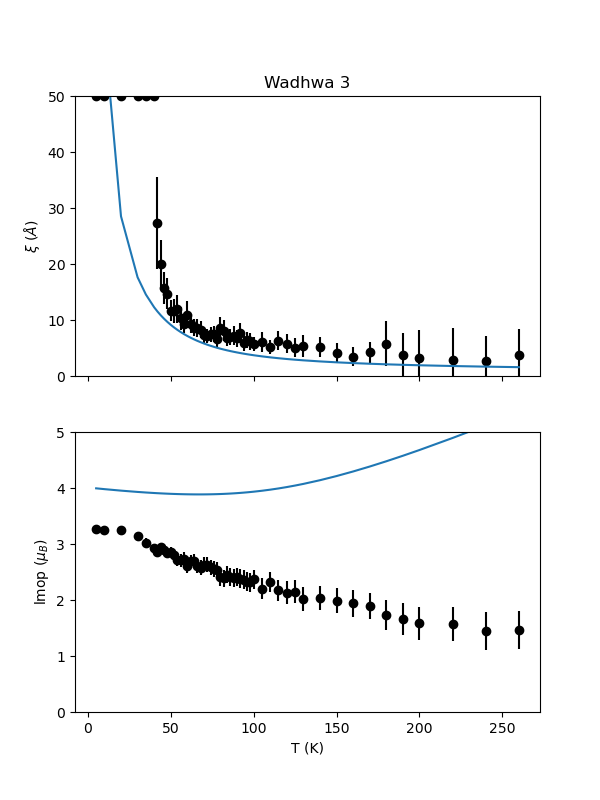

0.25717745055007046 -0.2571774505500705
1017.0176350547368


<IPython.core.display.Javascript object>


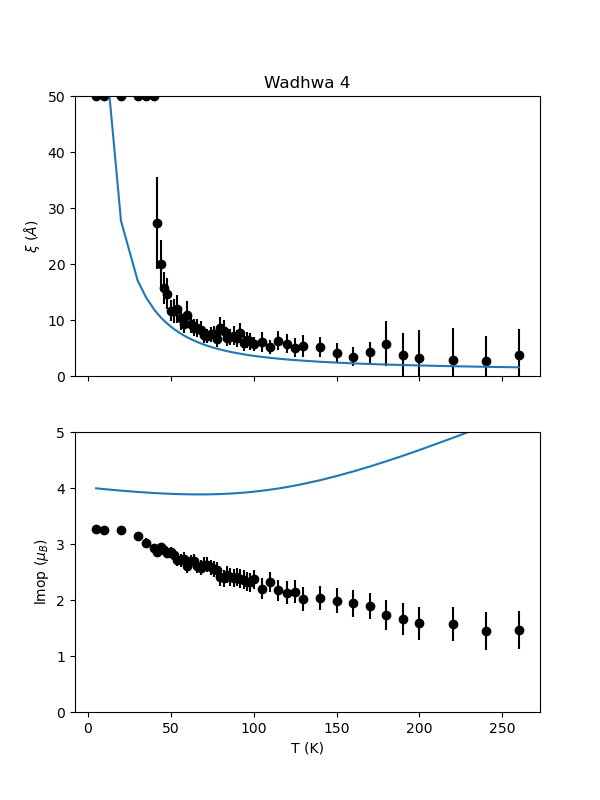

In [38]:
r_max = 5.0
n_ord_vec = 2
calc_orf = True
dim = 1

# spin_squared_list = [3.029502621455444, 2.9723206656016234, 2.1237506517324305,
#            3.664164472568528, 2.9304865092693193, 2.9951502492407354]

xis_list = np.zeros((len(j_ijs), len(temps)))
lmop_list = np.zeros((len(j_ijs), len(temps)))
spin_squared_list = np.zeros((len(j_ijs)))

for i, j_ij in enumerate(j_ijs):
    
    j1, j2 = j_ij

    j_ratio = j2 / j1
    kvecx = 0.5 + (np.arcsin(j_ratio * np.sqrt(1 - 0.25 * j_ratio**2)) - np.arccos(-0.5 * j_ratio)) / (2 * np.pi)
    kvecy = -np.arccos(-0.5 * j_ratio) / (2 * np.pi)
    
    print(kvecx, kvecy)
    
    def calc_corr_parameters(spin_sq):
        
        magint = maginteractions.MagInteractions(magstruc=magstruc, temperatures=temps, j_ij=j_ij,
                                                 spin_squared=spin_sq, r_max=r_max, spin_dim=3)
        magint.make_interaction_matrix()
        magint.filter_spin_positions()
        magint.calculate_orf_reciprocal_space(n_bz_vecs = 4)
        recip_orfs = magint.orfs.copy()

        ord_vec = np.array([kvecx, kvecy, 0]) @ magint.recip_lats

        magint.calculate_correlation_parameters(ord_vec=ord_vec, n_ord_vec=n_ord_vec, calc_orf=True,
                                                dim=dim, sum_rule_orf=False, n_bz_vecs=4, isotropic=False)
        xis = np.sort(np.linalg.eigvals(magint.damping_matrices), axis=1)[:,0]**(-1/2)
        
        return xis, magint.lmops
        
    
    def residuals(theta):
        spin_sq = theta[0]
        
        xis, lmops = calc_corr_parameters(theta[0])
        xis = xis[high_idx:]
        lmops = lmops[high_idx:]
        
        res = np.concatenate([xis,lmops]) - np.concatenate([xi_high_data, lmop_high_data])
        weights = 1/np.concatenate([xi_high_err,lmop_high_err])
        res *= weights
        res = np.nan_to_num(res,nan=1e4)
        return res
    
    bounds = (0, 6)
    theta = [4]
    result = least_squares(residuals, theta, method='dogbox', bounds=bounds)
    
    print(result.cost)
    
    xis, lmops = calc_corr_parameters(result.x[0])
    xis_list[i] = xis
    lmop_list[i] = lmops
    spin_squared_list[i] = result.x[0]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex = True, figsize = (6, 8))

    ax1.scatter(data_temps, xi_data, c = 'black')
    ax1.errorbar(data_temps, xi_data, yerr = xi_err, fmt = 'none', c = 'black')
    ax1.plot(temps, xis)
    ax1.set_ylim(0, 50)
    ax1.set_ylabel(r'$\xi$ ($\AA$)')
    ax1.set_title(j_ij_names[i])

    ax2.scatter(data_temps, lmop_data, c = 'black')
    ax2.errorbar(data_temps, lmop_data, yerr = lmop_err,fmt = 'none', c = 'black')
    ax2.plot(temps, magint.lmops)

    ax2.set_ylim(0, 5)
    ax2.set_xlabel('T (K)')
    ax2.set_ylabel(r'lmop ($\mu_B$)')

    plt.show()

In [39]:
residuals([4])

array([-5.32163714e-01,  3.95804051e-01,  1.65109830e+00,  1.74397784e+00,
        3.63972088e+00,  2.93475967e+00,  2.00280412e+00,  2.92822105e+00,
        3.66101909e+00,  1.65413821e+00,  2.95377066e+00,  3.22674424e+00,
        2.79449455e+00,  2.89891908e+00,  3.50763721e+00,  3.61518109e+00,
        3.01218005e+00,  2.50965031e+00,  2.99446705e+00,  8.47117445e-01,
        9.90837363e-01,  1.82965155e+00,  1.62967465e+00,  1.08158826e+00,
        1.39080901e+00,  4.40333328e-01,  1.59942256e+00,  1.08050974e+00,
        1.03105853e+00,  1.50451713e+00,  5.82209636e-01,  1.17896433e+00,
       -2.18178405e-02,  7.29374214e-02,  3.25087468e-01, -1.01714091e-02,
       -1.76019175e-01,  1.83883650e-01,  3.74672804e-01, -2.09073551e-01,
       -5.58668746e-01, -1.21039682e-01, -1.50622926e-02, -6.62153461e-03,
        5.18411314e-03, -2.89585621e-01,  1.22248468e+01,  1.16808436e+01,
        1.21724722e+01,  1.19638973e+01,  1.14615238e+01,  1.06386045e+01,
        1.03887124e+01,  

In [40]:
spin_squared_list

array([2.33602356, 2.22417027, 1.733265  , 2.85838998, 2.19880031,
       2.24020904])

<IPython.core.display.Javascript object>


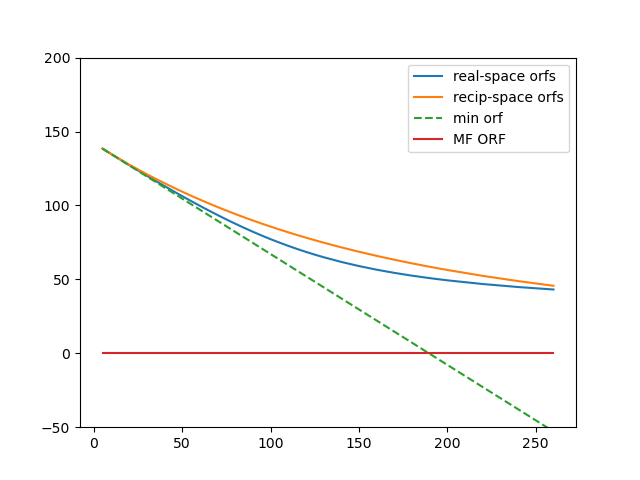

In [28]:
fig, ax = plt.subplots()
ax.plot(temps, magint.orfs, label = 'real-space orfs')
ax.plot(temps, recip_orfs, label = 'recip-space orfs')
# ax.plot(temps, experimental_orfs, label = 'experimental orfs')
ax.plot(temps, np.max(magint.j_q) - 3 * temps / spin_squared_list[-1], '--', label = 'min orf')
ax.plot(temps, np.zeros_like(temps), label = 'MF ORF')
ax.set_ylim(-50, 200)
ax.legend()
plt.show()

<IPython.core.display.Javascript object>


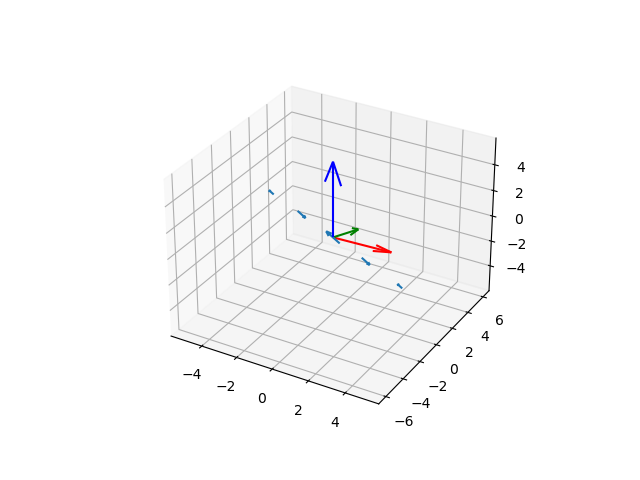

In [18]:
mPDF_tidx = 20

mstruc = magstruc.copy()
mstruc.dampingMat = magint.damping_matrices[mPDF_tidx]
mstruc.spins = mstruc.generateScaledSpins()

distances = np.apply_along_axis(np.linalg.norm, 1, mstruc.atoms)
viewmask = distances < 7
mstruc.visualize(mstruc.atoms[viewmask], mstruc.spins[viewmask], showcrystalaxes=True)

In [19]:
magint.damping_matrices[mPDF_tidx]

array([[ 3.36074156e+01,  6.11723290e+01,  7.44095288e-08],
       [ 6.11723290e+01,  1.11408638e+02, -4.08621521e-08],
       [ 7.44095288e-08, -4.08621521e-08,  1.45001553e+02]])

# Fit from previously published values

In [20]:
rmax = 5.0
S2 = 4
n_ordVec = 2
method = 'trf' # 'lm'
calcORF = True
dim = 1

def residuals(theta):
    
    j1, j2, s2 = theta
    Jij = [j1, j2]
    
    magint = maginteractions.MagInteractions(magstruc=magstruc,temps=Thigh,Jij=Jij,S2=s2,rmax=rmax)
    magint.makeMagLattice()
    magint.makeInteractionMatrix()
    if not calcORF:
        magint.calculateORF_reciprocalSpace(n_BZvecs=4)
        
    jrat = j2/j1
    kvecx = 0.5 + (np.arcsin(jrat*np.sqrt(1-0.25*jrat**2)) - np.arccos(-0.5*jrat))/(2*np.pi)
    kvecy = -np.arccos(-0.5*jrat)/(2*np.pi)
    ordVec = np.array([kvecx, kvecy, 0])@magint.recipLats
    
    magint.calc_lmop_dmat(ordVec=ordVec, n_ordVec=n_ordVec, dim=dim, calcORF = calcORF)
    xis = np.sort(np.linalg.eigvals(magint.dMat),axis=1)[:,1]**(-1/2)
    xis = np.where(xis>1e3, 1e3, xis)
    lmop = magint.lmop
    
    res = np.concatenate([xis,lmop]) - np.concatenate([xihigh,ordMomhigh])
    weights = 1/np.concatenate([xihigh_err,ordMomhigh_err])
    res *= weights
    res = np.nan_to_num(res,nan=1e4)
    return res

bounds = ([-np.inf, -np.inf, 0],[0, 0, np.inf])
theta = [-68, -0.1, 4]

result = least_squares(residuals, theta, method=method, bounds=bounds)

NameError: name 'Thigh' is not defined

In [ ]:
print(f'S^2 = {result.x[-1]}')
print(result.x[:-1]*8.617333262e-2,'meV')
print(f'cost = {result.cost}')

data = scale factor
Zorko: S2 = 3.029502621455444, cost = 11.816278687222617
Dally: S2 = 2.9723206656016234, cost = 12.14435770766481
Wadhwa1: S2 = 2.1237506517324305, cost = 163.37472935257904
Wadhwa2: S2 = 3.664164472568528, cost = 38.331986864926684
Wadhwa3: S2 = 2.9304865092693193, cost = 13.481227112252412
Wadhwa4: S2 = 2.9951502492407354, cost = 11.76402895620407

data = ordered moment
Zorko: S2 = 1.991495636996814, cost = 86.06371649886198
Dally: S2 = 1.9445765945393776, cost = 76.63006129886104
Wadhwa1: S2 = 1.3939310311887012, cost = 24.824181828497274
Wadhwa2: S2 = 2.4226044183604105, cost = 129.8764135467973
Wadhwa3: S2 = 1.9159055286861477, cost = 72.96382562362079
Wadhwa4: S2 = 1.9590751463110483, cost = 77.90938616773985

In [ ]:
print(-1 + np.sqrt(1 + 4*result.x[-1]))
print(np.sqrt(4*result.x[-1]))

In [ ]:
print(result.x)

print(result.jac.T@result.jac)
print(np.diag(result.jac.T@result.jac)**(-1/2))
print(np.diag(np.linalg.inv(result.jac.T@result.jac))**(1/2))

vals, vecs = np.linalg.eig(result.jac.T@result.jac)
for i in range(len(vals)):
    print(vals[i]**(-1/2))
    print(vecs[:,i])

In [ ]:
j1_fit, j2_fit, s2_fit = result.x
jij_fit = [j1_fit, j2_fit]

magint_fit = maginteractions.MagInteractions(magstruc=magstruc,temps=temps,Jij=jij_fit,S2=s2_fit,rmax=rmax)
magint_fit.makeMagLattice()
magint_fit.makeInteractionMatrix()
magint_fit.calculateORF_reciprocalSpace(n_BZvecs=4)

jrat = j2_fit/j1_fit
kvecx = 0.5 + (np.arcsin(jrat*np.sqrt(1-0.25*jrat**2)) - np.arccos(-0.5*jrat))/(2*np.pi)
kvecy = -np.arccos(-0.5*jrat)/(2*np.pi)
ordVec = np.array([kvecx, kvecy, 0])@magint.recipLats

magint_fit.calc_lmop_dmat(ordVec=ordVec, n_ordVec=n_ordVec, dim=dim, calcORF = calcORF)
xis_fit = np.sort(np.linalg.eigvals(magint_fit.dMat),axis=1)[:,1]**(-1/2)

In [ ]:
labelsize=12
ticksize=12

fig, (ax1, ax2) = plt.subplots(2,1,sharex=True, figsize=(6,8))
ax1.scatter(T,xi,c='black',label=r'data')
ax1.errorbar(T,xi,yerr=xi_err,fmt='none',c='black')
ax1.plot(temps,xis_fit,'-',label='fit')
# for i in range(4):
#     ax1.plot(temps,xis_list[i],'-',label='Wadhwa et al. interaction '+ str(i+1))
ax1.set_ylim(0,50)
ax1.set_xlabel('T (K)',fontsize=labelsize)
ax1.set_ylabel(r'$\xi$ ($\AA$)',fontsize=labelsize)
ax1.tick_params(axis='x', labelsize=ticksize)
ax1.tick_params(axis='y', labelsize=ticksize)

ax2.scatter(T,ordMom,c='black')
ax2.errorbar(T,ordMom,yerr=ordMom_err,fmt='none',c='black')
ax2.plot(temps,magint_fit.lmop,label='fit')
# for i in range(4):
#     ax2.plot(temps,lmop_list[i],'-',label='Wadhwa et al. '+ str(i+1))
ax2.set_ylim(0,5)
ax2.set_xlabel('T (K)',fontsize=labelsize)
ax2.set_ylabel(r'$m_{\mathrm{SRO}}$ ($\mu_B$)',fontsize=labelsize)
ax2.legend()
ax2.tick_params(axis='x', labelsize=ticksize)
ax2.tick_params(axis='y', labelsize=ticksize)

In [ ]:
mPDF_tidx = 10

paraScale = 0.01

mstruc = magstruc.copy()

mstruc.dampingMat = magint_fit.dMat[mPDF_tidx]
mc = MPDFcalculator(mstruc, qmax=35.0, qdamp=0.03)
mc.paraScale = paraScale
mc.ordScale = magutils.calculate_ordered_scale(mstruc,magint_fit.lmop[mPDF_tidx])
rcalc, dcalc = mc.calc(correlationMethod='full', normalized = False, both=False)

In [ ]:
np.linalg.eig(magint_fit.dMat[mPDF_tidx])

In [ ]:
from matplotlib.gridspec import GridSpec

labelsize=0.8*12
ticksize=0.8*12

fig = plt.figure(layout="constrained",figsize=(12,2.4))
gs = GridSpec(1, 4, figure=fig)
axmPDF = fig.add_subplot(gs[0,0:2])
ax1 = fig.add_subplot(gs[0,2])
ax2 = fig.add_subplot(gs[0,3])

axmPDF.plot(rcalc, dcalc,'y-', lw=2.5, label="mPDF(r) from exchange fits")
axmPDF.set_title('NaMnO2')
axmPDF.set_xlim(0.5,20)
axmPDF.set_xlabel(r'$r$ ($\AA$)',fontsize=labelsize)
axmPDF.set_ylabel(r'mPDF$(r)$ ',fontsize=labelsize)

ax1.scatter(T,xi,c='black',label=r'data')
ax1.errorbar(T,xi,yerr=xi_err,fmt='none',c='black')
ax1.plot(temps,xis_fit,'y-',label='fit',linewidth=3)
# for i in range(len(Jijs)-4):
#     ax1.plot(temps,xis_list[i],'--')
ax1.plot(temps,xis_list[0],'-.',c='tab:green')
ax1.plot(temps,xis_list[1],'--',c='tab:purple')
ax1.set_ylim(0,50)
ax1.set_xlabel('T (K)',fontsize=labelsize)
ax1.set_ylabel(r'$\xi$ ($\AA$)',fontsize=labelsize)
ax1.tick_params(axis='x', labelsize=ticksize)
ax1.tick_params(axis='y', labelsize=ticksize)

scale = 1 # 1.225
ax2.scatter(T,scale*ordMom,c='black')
ax2.errorbar(T,scale*ordMom,yerr=ordMom_err,fmt='none',c='black')
ax2.plot(temps,magint_fit.lmop,label='fit',c='y',linewidth=3)
# for i in range(len(Jijs)-4):
#     ax2.plot(temps,lmop_list[i],'--',label=Jij_names[i])
ax2.plot(temps,lmop_list[0],'-.',c='tab:green',label=Jij_names[0])
ax2.plot(temps,lmop_list[1],'--',c='tab:purple',label=Jij_names[1])
ax2.set_ylim(0,5)
ax2.set_xlabel('T (K)',fontsize=labelsize)
ax2.set_ylabel(r'$m_{\mathrm{SRO}}$ ($\mu_B$)',fontsize=labelsize)
ax2.legend(loc = 'upper right', fontsize=8)
ax2.tick_params(axis='x', labelsize=ticksize)
ax2.tick_params(axis='y', labelsize=ticksize)

plt.savefig('figures/NaMnO2Fits.png',dpi=600)
plt.show()

In [ ]:
for Jij in Jijs:
    print(f'Jij = {Jij}, J2/J1 = {Jij[1]/Jij[0]}')